# 537 — Sports pool / promotion simulator (live EDA)

**Typical session:** open **`sports/sim_config.py`** and this notebook side by side. Run **Cell 0** (optional), **Cell 1** (helpers), then **Cell 10** (widgets + plot). **Cell 11** (optional): histogram of **PPM** over the 530 **`player_season_panel_530.csv`** panel. See **`sports/documents/537_Manual.md`** for every knob, binning mode, and symbol.

Backup of the notebook **before batch cells were removed** (CELL 2–9 + archive banner): **`obsolete_files/sports_gameplan_old/537_Sports_Simulation_pre_archive_8MAy.ipynb`**.


In [11]:
### EDIT BLANK · session log

##### EDIT BLANK ###### DISCARD
# session: 2026-05-15 16:04 — Cell 10: LOO-gap additive promotion score (dropdown + helpers).

 #Burn cell for `.cursor/rules` diff sync. Not a numbered CELL.

# - Session marker: 2026-05-07 — initial 537 scaffold.
# - Session marker: 2026-05-07 — first-pass simulations 1-3.
# - Session marker: 2026-05-07 — reset promotion weight rules to defaults.
# - Session marker: 2026-05-07 — align plots to four diagnostic questions.
# - Session marker: 2026-05-07 — add optional convergence plots.
# - Session marker: 2026-05-07 — annotate plots with A_i distribution.
# - Session marker: 2026-05-07 — render A_i labels with mathtext.
# - Session marker: 2026-05-07 — annotate plots with pool sorting mode.
# - Session marker: 2026-05-07 — implement pure assortative pool option.
# - Session marker: 2026-05-07 — restructure plots into six requested diagnostics.
# - Session marker: 2026-05-07 — extend Cell 6 to full rollup progression.
# - Session marker: 2026-05-08 — MIN_ABILITY_FOR_PROMOTION (zero weights below cutoff; k_eff ≤ K) + Cell 10 slider.
# - Session marker: 2026-05-08 — CELL 10: Binning dropdown text + EDA HTML (Individuals vs Person x edges; pool modes unchanged).
# - Session marker: 2026-05-08 — CELL 10: sports/cell10_playground_state.json (reload widget defaults); Person x edges (equal-count vs equal-width).
# - Session marker: 2026-05-08 — CELL 10: run summary → widgets.HTML (not Output print; VS Code stream stack).
# - Session marker: 2026-05-08 — CELL 10: plot via widgets.Image + log Output; defer listeners; plt.ioff (fix stacked plots in VS Code/Cursor).
# - Session marker: 2026-05-08 — Operator manual → `sports/documents/537_Manual.md`.
# - Session marker: 2026-05-08 — CELL 10: PNG via BytesIO + IPython.Image in widget Output (no duplicate plots); annotate_simulation_context: 9pt, left, tighter y.
# - Session marker: 2026-05-08 — CELL 10: display(fig)+close(fig) instead of plt.show() (avoid duplicate inline plots).
# - Session marker: 2026-05-08 — Slim notebook: CELL 2–9 removed; backup → obsolete_files/sports_gameplan_old/537_Sports_Simulation_pre_archive_8MAy.ipynb.
# - Session marker: 2026-05-08 — equal-width pool bins; archive banner; 537_Manual; drop Cell 8a preset.
# - Session marker: 2026-05-08 — pool-mean-A binning (N_POOLS vs agg bins) + EDA binning mode in Cell 10.
# - Session marker: 2026-05-08 — Cell 10 single-panel EDA + FIG_PLAYGROUND_EDA_INCHES; ability & winner dropdowns.
# - Session marker: 2026-05-08 — standardized plot metadata block (Selection + full sim lineage).
# - Session marker: 2026-05-08 — fig sizes ~square panels + CELL 10: global _playground_ready (fix nonlocal SyntaxError).
# - Session marker: 2026-05-08 — CELL 10: wire batch lock + bins into UI; Cell 8a preset; avoid duplicate nonlocal.
# - Session marker: 2026-05-08 — CELL 10: batch-scale lock + bins slider + Cell 8a preset (sawtooth).
# - Session marker: 2026-05-08 — CELL 10: left = no-pool global-rank ref; center/right = pools + widget score; right x=global rank.
# - Session marker: 2026-05-08 — simulation context captions below axes (not upper legend box).
# - Session marker: 2026-05-08 — CELL 10: fix suptitle f-strings; disable additive w when local-rank-only.
# - Session marker: 2026-05-08 — add Plot 7a/7b: global rank x-axis under local-rank promotion.
# - Session marker: 2026-05-08 — add noisy sorting and 50/50 additive blend.
# - Session marker: 2026-05-08 — pause convergence and add standalone plot context.
# - Session marker: 2026-05-08 — add plot 7: local-rank promotions ordered by global rank.
# - Session marker: 2026-05-08 — move simulation choices into sports/sim_config.py.
# - Session marker: 2026-05-08 — add reload_sim_config calls to runnable cells.
# - Session marker: 2026-05-08 — Cell 10 interactive playground (ipywidgets).
# - Session marker: 2026-05-11 — RUN_CELL11 in sim_config + CELL 11 resolves flag.
# - Session marker: 2026-05-11 — User: burn log append-only at bottom; no agent deletions; use user-stated "today".
# - Session marker: 2026-05-11 13:07 — marker rows: date after colon = calendar day line is added.
# - Session marker: 2026-05-11 13:09 — burn log: YYYY-MM-DD HH:MM (local) after colon on session + new marker rows.
# - Session marker: 2026-05-11 13:14 — archived # session: Session marker rows sorted ascending by date/time.
# - Session marker: 2026-05-11 13:19 — archived # session: CELL 11 PPM three-stack / sharex / drafted mid / blue-green bottom.
# - Session marker: 2026-05-11 13:54 — archived # session: CELL 11 panel 3: secondary y-axis for drafted bin counts.

# - Session marker: 2026-05-15 16:04 — Cell 10: widget-authoritative knobs + shared catalog with sweep PNG titles.


### CELL 0 — Config · A/B/C choices

This cell makes the first modeling forks explicit. For the first pass we implement the A choices and leave the B/C choices visible as planned extensions.

In [12]:
# CELL 0 — Load simulation config

from pathlib import Path
import importlib.util

CONFIG_CANDIDATES = [Path("sports/sim_config.py"), Path("sim_config.py")]


def reload_sim_config(verbose: bool = True):
    """Reload sports/sim_config.py and refresh all uppercase config variables."""
    sim_config_path = next((path for path in CONFIG_CANDIDATES if path.exists()), None)
    if sim_config_path is None:
        raise FileNotFoundError("Could not find sim_config.py in ./sports/ or current directory.")

    spec = importlib.util.spec_from_file_location("sim_config", sim_config_path)
    sim_config = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(sim_config)

    for name in dir(sim_config):
        if name.isupper():
            globals()[name] = getattr(sim_config, name)

    globals()["SIM_CONFIG_PATH"] = sim_config_path
    globals()["sim_config"] = sim_config

    if verbose:
        print("Reloaded simulation config from", sim_config_path)
        print(
            f"N={N_INDIVIDUALS}, K={N_WINNERS}, pools={N_POOLS}, runs={N_RUNS}, "
            f"ability_choice={ABILITY_DISTRIBUTION_CHOICE!r}, winner_choice={WINNER_SELECTION_CHOICE!r}, "
            f"pool_choices={LOCAL_POOL_ASSIGNMENT_CHOICES_SIM3}, sorting_noise_sd={SORTING_NOISE_SD}, "
            f"additive_w={ADDITIVE_LOCAL_RANK_WEIGHT}, min_A_promote={MIN_ABILITY_FOR_PROMOTION}, "
            f"convergence={SHOW_CONVERGENCE_PLOTS} · RUN_CELL11={RUN_CELL11!r}"
        )
    return sim_config

# Repo root holds ``functionsG_working.py``; cwd is often ``.../sports`` (invalid: ``from ../...``).
import sys as _sys

_here = Path.cwd().resolve()
_root = next(
    (p for p in (_here, *_here.parents) if (p / "functionsG_working.py").is_file()),
    None,
)
if _root is None:
    raise FileNotFoundError(f"functionsG_working.py not found at or above {_here}")
_r = str(_root)
if _r not in _sys.path:
    _sys.path.insert(0, _r)
from functionsG_working import tyme  # noqa: E402


reload_sim_config()
print("CELL 0 ready")

Reloaded simulation config from sim_config.py
N=1000, K=50, pools=50, runs=500, ability_choice='B', winner_choice='A', pool_choices=('A', 'B'), sorting_noise_sd=0.01, additive_w=0.0, min_A_promote=0.0, convergence=False · RUN_CELL11=True
CELL 0 ready


### CELL 1 — Imports and simulation helpers

These helpers keep the simulations comparable. Each scenario produces individual-run rows with ability, rank, optional pool fields, and a promoted flag.

In [13]:
# CELL 1 — Imports and simulation helpers

reload_sim_config()

if RUN_CELL1:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from IPython.display import display

    # Inches per subplot row/column so multi-panel figures have nearly square axes.
    FIG_PANEL_IN = 5.8

    def figsize_grid(nrows: int, ncols: int) -> tuple[float, float]:
        """Figure (width, height) for an nrows×ncols grid of nearly square subplots."""
        p = FIG_PANEL_IN
        return (p * ncols, p * nrows)

    def generate_ability(rng: np.random.Generator, n: int, choice: str = "A") -> np.ndarray:
        """Generate individual ability A_i for one mock population."""
        if choice == "A":
            return rng.uniform(0.0, 1.0, size=n)
        if choice == "B":
            vals = rng.normal(loc=0.5, scale=0.18, size=n)
            return np.clip(vals, 0.0, 1.0)
        if choice == "C":
            vals = rng.beta(a=2.0, b=5.0, size=n)
            return vals / vals.max() if vals.max() > 0 else vals
        raise ValueError(f"Unknown ability distribution choice: {choice!r}")

    def rank_score(values: np.ndarray) -> np.ndarray:
        """Percentile-like rank score in (0, 1], where larger values are better."""
        s = pd.Series(values)
        return s.rank(method="average", pct=True).to_numpy(dtype=float)

    def normalized_weights(score: np.ndarray) -> np.ndarray:
        """Convert nonnegative scores into a probability vector."""
        w = np.asarray(score, dtype=float)
        w = np.where(np.isfinite(w), w, 0.0)
        w = np.clip(w, 0.0, None)
        total = float(w.sum())
        if total <= 0:
            return np.full(len(w), 1.0 / len(w))
        return w / total

    def choose_winners(
        rng: np.random.Generator,
        weights: np.ndarray,
        k: int,
        choice: str = "A",
    ) -> np.ndarray:
        """Return a boolean winner vector for one run.

        Rows with zero weight (e.g. below minimum-ability cutoff) are never selected.
        At most ``min(k, count(weight > 0))`` winners are returned when ``choice`` is A or C.
        """
        n = len(weights)
        w = np.asarray(weights, dtype=float)
        w = np.where(np.isfinite(w), w, 0.0)
        w = np.clip(w, 0.0, None)
        n_positive = int(np.count_nonzero(w > 0))
        if n_positive == 0:
            return np.zeros(n, dtype=bool)
        k_eff = min(int(k), n_positive)
        if choice == "A":
            p = normalized_weights(w)
            idx = rng.choice(n, size=k_eff, replace=False, p=p)
            winners = np.zeros(n, dtype=bool)
            winners[idx] = True
            return winners
        if choice == "B":
            p = np.minimum(normalized_weights(w) * k, 1.0)
            return rng.uniform(size=n) < p
        if choice == "C":
            idx = np.argsort(w, kind="mergesort")[-k_eff:]
            winners = np.zeros(n, dtype=bool)
            winners[idx] = True
            return winners
        raise ValueError(f"Unknown winner selection choice: {choice!r}")

    def equal_pool_template(n: int, n_pools: int) -> np.ndarray:
        """Pool labels with approximately equal pool sizes."""
        return np.repeat(np.arange(n_pools), int(np.ceil(n / n_pools)))[:n]

    def sorting_signal_for_pools(
        rng: np.random.Generator,
        ability: np.ndarray,
        sorting_noise_sd: float = 0.0,
    ) -> np.ndarray:
        """Noisy signal used only for pool assignment; true A_i is unchanged."""
        noise_sd = max(float(sorting_noise_sd), 0.0)
        if noise_sd == 0.0:
            return np.asarray(ability, dtype=float)
        return np.asarray(ability, dtype=float) + rng.normal(loc=0.0, scale=noise_sd, size=len(ability))

    def assign_pool_ids(
        rng: np.random.Generator,
        ability: np.ndarray,
        n_pools: int,
        choice: str = "A",
        sorting_noise_sd: float = 0.0,
    ) -> tuple[np.ndarray, np.ndarray]:
        """Assign individuals to pools under random, assortative, or disassortative sorting."""
        n = len(ability)
        base = equal_pool_template(n, n_pools)
        pool_id = np.empty(n, dtype=int)
        signal = sorting_signal_for_pools(rng, ability, sorting_noise_sd)
        if choice == "A":
            return rng.permutation(base), signal
        order = np.argsort(signal)
        if choice == "B":
            # Assortative: adjacent sorting-signal ranks are grouped into the same pool.
            pool_id[order] = base
            return pool_id, signal
        if choice == "C":
            # Disassortative: adjacent sorting-signal ranks are spread across pools.
            pool_id[order] = np.arange(n) % n_pools
            return pool_id, signal
        raise ValueError(f"Unknown local pool assignment choice: {choice!r}")

    def add_pool_fields(df: pd.DataFrame) -> pd.DataFrame:
        """Add pool quality, leave-one-out (LOO) peer mean A, and local rank fields."""
        out = df.copy()
        g = out.groupby(["run", "pool_id"], observed=True)["A"]
        sum_a = g.transform("sum")
        cnt = g.transform("count")
        den = (cnt - 1).astype(float)
        den = den.replace(0.0, np.nan)
        out["pool_quality"] = sum_a / cnt.astype(float)
        out["poolq_loo"] = (sum_a - out["A"]) / den
        out["local_rank_score"] = out.groupby(["run", "pool_id"], observed=True)["A"].rank(method="average", pct=True)
        return out

    def summarize_by_bins(
        df: pd.DataFrame,
        x_col: str,
        n_bins: int = 10,
        label: str | None = None,
        *,
        person_binning: str = "equal_count",
    ) -> pd.DataFrame:
        """Bin x_col and summarize observed promotion probability.

        ``person_binning``:
        - ``equal_count``: tie-broken ``rank(method='first')`` then ``pd.qcut`` →
          near-equal **row counts** per bin (stable for discrete ``x_col``).
        - ``equal_width``: ``pd.cut`` on ``[min(x), max(x)]`` into ``n_bins``
          intervals (counts can be very unequal).
        """
        work = df.dropna(subset=[x_col, "promoted"]).copy()
        method = str(person_binning).strip().lower().replace("-", "_")
        if method in ("equal_count", "quantile", "qcut"):
            r = work[x_col].rank(method="first", ascending=True)
            work["bin"] = pd.qcut(r, q=n_bins, labels=False, duplicates="drop")
        elif method in ("equal_width", "width", "cut"):
            x = work[x_col].to_numpy(dtype=float)
            lo, hi = float(np.nanmin(x)), float(np.nanmax(x))
            if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
                work["bin"] = 0
            else:
                edges = np.linspace(lo, hi, int(n_bins) + 1)
                work["bin"] = pd.cut(
                    work[x_col],
                    bins=edges,
                    labels=False,
                    include_lowest=True,
                    duplicates="drop",
                )
        else:
            raise ValueError(f"unknown person_binning: {person_binning!r}")
        summary = (
            work.dropna(subset=["bin"])
            .groupby("bin", observed=True)
            .agg(
                x_mean=(x_col, "mean"),
                promotion_rate=("promoted", "mean"),
                n=("promoted", "size"),
            )
            .reset_index()
        )
        summary["x_col"] = label or x_col
        return summary

    def summarize_by_pool_mean_A_bins(
        df: pd.DataFrame,
        n_pool_bins: int,
        *,
        method: str = "equal_count",
        label: str | None = None,
    ) -> pd.DataFrame:
        """Bin *pools* by mean A_i, then average promotion within each bin.

        ``method``:
        - ``equal_count``: sort pools by mean A; ``numpy.array_split`` into ``K`` groups
          (as equal pool counts as possible). Needs ``K <=`` pools per run.
        - ``equal_width``: within each run, ``K`` equal-width intervals on
          ``[min mean A, max mean A]`` across pools (``pd.cut``). Bins can be empty;
          Q order follows increasing mean-A intervals.

        ``x_loo_mean`` is the mean leave-one-out peer ability in the bin (530-style ``poolq_loo``
        on ability); ``x_mean`` remains mean individual ``A`` in the bin. Rows sorted by
        ``x_loo_mean`` (low → high LOO peer talent).
        """
        need = {"run", "pool_id", "A", "promoted", "poolq_loo"}
        missing = need - set(df.columns)
        if missing:
            raise ValueError(
                f"summarize_by_pool_mean_A_bins missing columns: {missing}. "
                "Simulation rows need add_pool_fields() (provides poolq_loo)."
            )

        if method not in ("equal_count", "equal_width"):
            raise ValueError("method must be 'equal_count' or 'equal_width'")

        n_pool_bins = int(n_pool_bins)
        if n_pool_bins < 2:
            raise ValueError("n_pool_bins must be at least 2")

        work = df.dropna(subset=["A", "promoted", "pool_id"]).copy()
        work["pool_id"] = work["pool_id"].astype(np.int64)

        def pool_bin_map_for_run(sub: pd.DataFrame) -> pd.DataFrame:
            run_id = int(sub["run"].iloc[0])
            pool_mean = sub.groupby("pool_id", observed=True)["A"].mean()
            n_pools_run = int(pool_mean.shape[0])

            if method == "equal_count":
                pool_mean = pool_mean.sort_values(kind="mergesort")
                if n_pool_bins > n_pools_run:
                    raise ValueError(
                        f"n_pool_bins ({n_pool_bins}) exceeds number of pools in a run ({n_pools_run})"
                    )
                pool_ids = pool_mean.index.to_numpy(dtype=np.int64)
                chunks = np.array_split(pool_ids, n_pool_bins)
                rows = [(run_id, int(pid), int(b)) for b, chunk in enumerate(chunks) for pid in chunk]
                return pd.DataFrame(rows, columns=["run", "pool_id", "pool_A_bin"])

            lo = float(np.min(pool_mean.to_numpy(dtype=float)))
            hi = float(np.max(pool_mean.to_numpy(dtype=float)))
            if hi <= lo:
                rows = [(run_id, int(pid), 0) for pid in pool_mean.index]
                return pd.DataFrame(rows, columns=["run", "pool_id", "pool_A_bin"])
            edges = np.linspace(lo, hi, n_pool_bins + 1)
            cats = pd.cut(pool_mean, bins=edges, include_lowest=True)
            codes = cats.cat.codes.to_numpy(dtype=np.int64)
            rows = [(run_id, int(pid), int(c)) for pid, c in zip(pool_mean.index, codes)]
            return pd.DataFrame(rows, columns=["run", "pool_id", "pool_A_bin"])

        maps = [pool_bin_map_for_run(sub) for _, sub in work.groupby("run", observed=True, sort=False)]
        pmap = pd.concat(maps, ignore_index=True)
        merged = work.merge(pmap, on=["run", "pool_id"], how="inner")
        per_run = (
            merged.groupby(["run", "pool_A_bin"], observed=True)
            .agg(
                x_mean=("A", "mean"),
                x_loo_mean=("poolq_loo", "mean"),
                promotion_rate=("promoted", "mean"),
                n=("promoted", "size"),
                n_pools=("pool_id", "nunique"),
            )
            .reset_index()
        )
        summary = (
            per_run.groupby("pool_A_bin", observed=True)
            .agg(
                x_mean=("x_mean", "mean"),
                x_loo_mean=("x_loo_mean", "mean"),
                promotion_rate=("promotion_rate", "mean"),
                n=("n", "sum"),
                n_pools=("n_pools", "mean"),
            )
            .reset_index()
            .sort_values("x_loo_mean", kind="mergesort")
            .reset_index(drop=True)
        )
        summary["x_col"] = label or "pool_mean_A_bins"
        return summary

    ABILITY_DISTRIBUTION_LABELS = {
        "A": r"$A_i \sim \mathrm{Uniform}(0, 1)$",
        "B": r"$A_i \sim \mathrm{clipped\ Normal}(0.5, 0.18)$",
        "C": r"$A_i \sim \mathrm{scaled\ Beta}(2, 5)$",
    }

    def ability_distribution_label(choice: str) -> str:
        """Human-readable ability distribution note for plot annotations."""
        return ABILITY_DISTRIBUTION_LABELS.get(choice, rf"$A_i$ distribution choice={choice!r}")

    POOL_SORTING_LABELS = {
        None: "Pools: none",
        "A": "Pools: random equal-sized",
        "B": "Pools: pure assortative",
        "C": "Pools: pure disassortative",
    }

    def pool_sorting_label(choice: str | None) -> str:
        """Human-readable pool sorting note for plot annotations."""
        return POOL_SORTING_LABELS.get(choice, f"Pools: sorting choice={choice!r}")

    WINNER_SELECTION_LABELS = {
        "A": "Weighted sample without replacement of K winners",
        "B": "Independent Bernoulli using min(normalized_weight×K, 1)",
        "C": "Deterministic top-K by promotion score",
    }

    def format_plot_na(value) -> str:
        if value is None:
            return "N/A"
        return str(value)

    def promotion_selection_label(score_mode: str, local_rank_weight: float | None = None) -> str:
        if score_mode == "ability":
            return "A_i"
        if score_mode == "global_rank":
            return "Global rank"
        if score_mode == "local_rank":
            return "Local rank"
        if score_mode == "local_rank_plus_ability":
            w = float(local_rank_weight) if local_rank_weight is not None else float("nan")
            return f"Additive (local rank), w={w:.3f}"
        if score_mode == "loo_gap_plus_ability":
            w = float(local_rank_weight) if local_rank_weight is not None else float("nan")
            return f"Additive (A−LOO pool q), w={w:.3f}"
        return f"(unknown score_mode={score_mode!r})"

    def build_plot_meta(
        *,
        score_mode: str,
        x_binned: str,
        seed: int,
        winner_choice: str | None = None,
        ability_choice: str | None = None,
        pool_assignment_choice: str | None = None,
        n_pools: int | None = None,
        sorting_noise_sd: float | None = None,
        local_rank_weight: float | None = None,
        min_ability_for_promotion: float | None = None,
        n_individuals: int | None = None,
        n_winners: int | None = None,
        n_runs: int | None = None,
        n_bins: int | None = None,
        caption_extra: str | None = None,
    ) -> dict:
        return {
            "ability_choice": ability_choice if ability_choice is not None else ABILITY_DISTRIBUTION_CHOICE,
            "score_mode": score_mode,
            "winner_choice": winner_choice if winner_choice is not None else WINNER_SELECTION_CHOICE,
            "pool_assignment_choice": pool_assignment_choice,
            "n_pools": n_pools,
            "sorting_noise_sd": sorting_noise_sd,
            "local_rank_weight": local_rank_weight,
            "min_ability_for_promotion": float(
                min_ability_for_promotion
                if min_ability_for_promotion is not None
                else globals().get("MIN_ABILITY_FOR_PROMOTION", 0.0)
            ),
            "n_individuals": int(n_individuals if n_individuals is not None else N_INDIVIDUALS),
            "n_winners": int(n_winners if n_winners is not None else N_WINNERS),
            "n_runs": int(n_runs if n_runs is not None else N_RUNS),
            "n_bins": int(n_bins if n_bins is not None else N_BINS),
            "seed": int(seed),
            "x_binned": x_binned,
            "caption_extra": caption_extra,
        }

    def annotate_simulation_context(ax, plot_meta: dict):
        """Standardized metadata under each panel: Selection + full simulation lineage."""
        ac = plot_meta["ability_choice"]
        sm = plot_meta["score_mode"]
        wc = plot_meta["winner_choice"]
        pool_c = plot_meta.get("pool_assignment_choice")
        n_pools = plot_meta.get("n_pools")
        snd = plot_meta.get("sorting_noise_sd")
        lr_w = plot_meta.get("local_rank_weight")
        n_i = plot_meta["n_individuals"]
        n_k = plot_meta["n_winners"]
        n_r = plot_meta["n_runs"]
        n_b = plot_meta["n_bins"]
        seed = plot_meta["seed"]
        xb = plot_meta["x_binned"]
        min_promo_a = plot_meta.get("min_ability_for_promotion")

        pool_line = pool_sorting_label(pool_c)
        if snd is not None and float(snd) > 0.0 and pool_c == "B":
            pool_line = "Pools: noisy assortative"
        elif snd is not None and float(snd) > 0.0 and pool_c == "C":
            pool_line = "Pools: noisy disassortative"

        draw_txt = WINNER_SELECTION_LABELS.get(wc, f"winner_choice={wc!r}")

        if sm in ("local_rank_plus_ability", "loo_gap_plus_ability") and lr_w is not None:
            w_line = f"{float(lr_w):.3f}"
        else:
            w_line = "N/A"

        if snd is None:
            noise_line = "N/A"
        else:
            noise_line = f"{float(snd):.4f}"

        if min_promo_a is None:
            min_a_line = f"{float(globals().get('MIN_ABILITY_FOR_PROMOTION', 0.0)):.3f}"
        else:
            min_a_line = f"{float(min_promo_a):.3f}"

        if sm == "loo_gap_plus_ability":
            w_share_txt = "LOO-gap share in additive score"
        else:
            w_share_txt = "local-rank share in additive score"

        sel_w = lr_w if sm in ("local_rank_plus_ability", "loo_gap_plus_ability") else None
        lines = [
            f"Selection: {promotion_selection_label(sm, sel_w)}",
            f"X-axis (binned): {xb}",
            f"Ability: {ability_distribution_label(ac)}",
            pool_line,
            f"Pool assignment: {format_plot_na(pool_c)}",
            f"N pools: {format_plot_na(n_pools)}",
            f"Sorting noise sd: {noise_line}",
            f"w ({w_share_txt}): {w_line}",
            f"Min $A_i$ for promotion: {min_a_line}",
            f"Draw: {draw_txt} ({wc})",
            f"N={n_i:,}; K={n_k}; runs={n_r:,}; bins={n_b}",
            f"Seed: {seed}",
        ]
        extra = plot_meta.get("caption_extra")
        if extra:
            lines.append(extra)
        ax.text(
            0.02,
            -0.10,
            "\n".join(lines),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9.0,
            color="0.28",
            clip_on=False,
        )
    def plot_bin_summary(
        summary: pd.DataFrame,
        title: str,
        xlabel: str,
        ax=None,
        *,
        show_simulation_context: bool = True,
        plot_meta: dict | None = None,
    ):
        """Plot binned promotion probability for one diagnostic relationship."""
        if ax is None:
            _, ax = plt.subplots(figsize=(FIG_PANEL_IN, FIG_PANEL_IN * 0.97))
        ax.plot(summary["x_mean"], summary["promotion_rate"], "o-", color="steelblue")
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Estimated promotion probability")
        ax.grid(True, alpha=0.3)
        if show_simulation_context:
            if plot_meta is None:
                raise ValueError("plot_meta is required when show_simulation_context=True")
            annotate_simulation_context(ax, plot_meta)
        return ax

    def plot_pool_A_bin_summary(
        summary: pd.DataFrame,
        title: str,
        ax=None,
        *,
        show_simulation_context: bool = True,
        plot_meta: dict | None = None,
    ):
        """Line plot: promotion vs mean LOO peer A in each pool–talent bin (Q scale, not Q1..QK index)."""
        if ax is None:
            _, ax = plt.subplots(figsize=(FIG_PANEL_IN, FIG_PANEL_IN * 0.97))
        s = summary.sort_values("x_loo_mean", kind="mergesort")
        ax.plot(
            s["x_loo_mean"],
            s["promotion_rate"],
            "o-",
            color="steelblue",
            markersize=5.5,
            linewidth=1.35,
        )
        ax.set_title(title)
        ax.set_xlabel(r"Mean leave-one-out peer $A$ in bin (sim.; analog to poolq_loo)")
        ax.set_ylabel("Estimated promotion probability")
        ax.grid(True, alpha=0.3)
        if show_simulation_context:
            if plot_meta is None:
                raise ValueError("plot_meta is required when show_simulation_context=True")
            annotate_simulation_context(ax, plot_meta)
        return ax

    def maybe_save_figure(fig, filename_stem: str):
        """Save a figure only when SAVE_FIGURES is enabled in sim_config.py."""
        if not globals().get("SAVE_FIGURES", False):
            return None
        out_dir = Path("sports/outputs/simulation_figures")
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / f"{filename_stem}.png"
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        print("Saved figure:", out_path)
        return out_path

    def show_figure(fig, filename_stem: str | None = None):
        """Display inline and close the figure; optionally save through maybe_save_figure."""
        if filename_stem is not None:
            maybe_save_figure(fig, filename_stem)
        display(fig)
        plt.close(fig)

    def simulate_population_rows(
        *,
        seed: int,
        n_runs: int,
        n: int,
        k: int,
        ability_choice: str,
        winner_choice: str,
        score_mode: str,
        include_random_pools: bool = False,
        n_pools: int | None = None,
        pool_assignment_choice: str = "A",
        sorting_noise_sd: float = 0.0,
        local_rank_weight: float = 0.5,
        min_ability_for_promotion: float | None = None,
    ) -> pd.DataFrame:
        """Simulate repeated mock populations under one selection rule."""
        rng = np.random.default_rng(seed)
        rows: list[pd.DataFrame] = []
        mcut = float(
            min_ability_for_promotion
            if min_ability_for_promotion is not None
            else globals().get("MIN_ABILITY_FOR_PROMOTION", 0.0)
        )
        for run in range(n_runs):
            A = generate_ability(rng, n, ability_choice)
            global_rank = rank_score(A)
            if include_random_pools:
                if n_pools is None:
                    raise ValueError("n_pools is required when include_random_pools=True")
                pool_id, sorting_signal = assign_pool_ids(
                    rng,
                    A,
                    n_pools,
                    choice=pool_assignment_choice,
                    sorting_noise_sd=sorting_noise_sd,
                )
                one = pd.DataFrame(
                    {
                        "run": run,
                        "person": np.arange(n),
                        "A": A,
                        "sorting_signal": sorting_signal,
                        "global_rank_score": global_rank,
                        "pool_id": pool_id,
                    }
                )
                one = add_pool_fields(one)
            else:
                one = pd.DataFrame({"run": run, "person": np.arange(n), "A": A, "global_rank_score": global_rank})

            if score_mode == "ability":
                weights = one["A"].to_numpy(dtype=float)
            elif score_mode == "global_rank":
                weights = one["global_rank_score"].to_numpy(dtype=float)
            elif score_mode == "local_rank":
                weights = one["local_rank_score"].to_numpy(dtype=float)
            elif score_mode == "local_rank_plus_ability":
                w = float(local_rank_weight)
                weights = w * one["local_rank_score"].to_numpy(dtype=float) + (1.0 - w) * one["A"].to_numpy(dtype=float)
            elif score_mode == "loo_gap_plus_ability":
                w = float(local_rank_weight)
                A_arr = one["A"].to_numpy(dtype=float)
                q_arr = one["poolq_loo"].to_numpy(dtype=float)
                base = w * (A_arr - q_arr) + (1.0 - w) * A_arr
                weights = np.where(np.isfinite(q_arr), base, A_arr)
            else:
                raise ValueError(f"Unknown score_mode: {score_mode!r}")

            if mcut > 0.0:
                A_arr = one["A"].to_numpy(dtype=float)
                weights = np.where(A_arr >= mcut, weights, 0.0)

            one["promoted"] = choose_winners(rng, weights, k, winner_choice)
            rows.append(one)
        return pd.concat(rows, ignore_index=True)

    def checkpoint_list(checkpoints: list[int], max_runs: int) -> list[int]:
        """Keep positive unique checkpoints up to max_runs, always including max_runs."""
        vals = sorted({int(c) for c in checkpoints if 0 < int(c) <= int(max_runs)})
        if int(max_runs) not in vals:
            vals.append(int(max_runs))
        return vals

    def convergence_summaries(
        *,
        seed: int,
        checkpoints: list[int],
        n: int,
        k: int,
        ability_choice: str,
        winner_choice: str,
        score_mode: str,
        x_col: str,
        n_bins: int,
        include_random_pools: bool = False,
        n_pools: int | None = None,
        pool_assignment_choice: str = "A",
        sorting_noise_sd: float = 0.0,
        local_rank_weight: float = 0.5,
        min_ability_for_promotion: float | None = None,
    ) -> dict[int, pd.DataFrame]:
        """Run one scenario at multiple iteration counts and return binned summaries."""
        out: dict[int, pd.DataFrame] = {}
        for n_runs in checkpoints:
            sim = simulate_population_rows(
                seed=seed,
                n_runs=n_runs,
                n=n,
                k=k,
                ability_choice=ability_choice,
                winner_choice=winner_choice,
                score_mode=score_mode,
                include_random_pools=include_random_pools,
                n_pools=n_pools,
                pool_assignment_choice=pool_assignment_choice,
                sorting_noise_sd=sorting_noise_sd,
                local_rank_weight=local_rank_weight,
                min_ability_for_promotion=min_ability_for_promotion,
            )
            out[n_runs] = summarize_by_bins(sim, x_col, n_bins, label=x_col)
        return out

    def plot_convergence_summaries(
        summaries: dict[int, pd.DataFrame],
        title: str,
        xlabel: str,
        ax=None,
        *,
        show_simulation_context: bool = True,
        plot_meta: dict | None = None,
    ):
        """Overlay checkpoint curves so noisy estimates visibly settle as runs increase."""
        if ax is None:
            _, ax = plt.subplots(figsize=(FIG_PANEL_IN * 1.65, FIG_PANEL_IN * 1.65))
        items = sorted(summaries.items())
        for idx, (n_runs, summary) in enumerate(items):
            alpha = 0.25 + 0.75 * ((idx + 1) / len(items))
            linewidth = 1.0 + 1.4 * ((idx + 1) / len(items))
            ax.plot(
                summary["x_mean"],
                summary["promotion_rate"],
                "o-",
                alpha=alpha,
                linewidth=linewidth,
                markersize=3.5,
                label=f"runs={n_runs}",
            )
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Estimated promotion probability")
        ax.grid(True, alpha=0.3)
        if show_simulation_context:
            if plot_meta is None:
                raise ValueError("plot_meta is required when show_simulation_context=True")
            annotate_simulation_context(ax, plot_meta)
        ax.legend(loc="upper right", fontsize=8)
        return ax
    print("CELL 1 ready: helpers loaded")
else:
    print("CELL 1 skipped (RUN_CELL1 = False)")


Reloaded simulation config from sim_config.py
N=1000, K=50, pools=50, runs=500, ability_choice='B', winner_choice='A', pool_choices=('A', 'B'), sorting_noise_sd=0.01, additive_w=0.0, min_A_promote=0.0, convergence=False · RUN_CELL11=True
CELL 1 ready: helpers loaded


### CELL 10 — Interactive EDA (one plot + knobs)

**Cell 1** once per kernel. **`sim_config.py`** supplies **starting defaults** only; the **sliders and dropdowns on this panel are authoritative** for the figure. After editing `sim_config.py`, run **Cell 0** and click **Load defaults from sim_config.py** in Cell 10 to copy those values into the widgets.

- **Binning · Individuals** — bin the plotted **x** into *Person bins*; equal-count vs equal-width comes from **Person x edges**.
- **Binning · Pools · equal count** — sort teams by pool mean \(A_i\), split into **Pool–talent bins (#)** near-equal pool groups. Requires **Pools (#) ≥ Pool–talent bins (#)**. **Plot x-axis:** mean **leave-one-out peer** \(A\) in each pool–talent bin (`poolq_loo`).
- **Binning · Pools · equal width** — equal-width intervals on \([\min,\max]\) of pool mean \(A\); **plot x-axis** still mean LOO peer \(A\) in bin.

For pool binning, choose **Binning →** a **Pools:** option and a **pooled** plot view (`With pools: …`). **Promotions per run (K)** is winners per run; do not confuse with **Pool–talent bins (#)**.

Faithful sweep **`candidate_*.png`** titles use the same knob phrases as these widgets (`cell10_knob_catalog.py`). Full reference: **`sports/documents/537_Manual.md`**.

`ipywidgets` required. **Run / refresh** updates the figure.

In [16]:
# CELL 10 — Interactive playground (ipywidgets)

from pathlib import Path

reload_sim_config()

if not RUN_CELL_PLAYGROUND:
    print("CELL 10 skipped (RUN_CELL_PLAYGROUND = False)")
else:
    _p = Path("sports/cell10_playground_run.py")
    if not _p.is_file():
        _p = Path("cell10_playground_run.py")
    if not _p.is_file() and Path.cwd().name == "sports":
        _p = Path("cell10_playground_run.py")
    if not _p.is_file():
        raise FileNotFoundError(
            "Missing cell10_playground_run.py — run from the Ivy_Net repo root "
            f"(cwd={Path.cwd().resolve()})"
        )
    exec(compile(_p.read_text(encoding="utf-8"), str(_p.resolve()), "exec"), globals())


Reloaded simulation config from sim_config.py
N=1000, K=50, pools=50, runs=500, ability_choice='B', winner_choice='A', pool_choices=('A', 'B'), sorting_noise_sd=0.01, additive_w=0.0, min_A_promote=0.0, convergence=False · RUN_CELL11=True


### CELL 11 — PPM distribution (530 panel)

**Data:** **`player_season_panel_530.csv`** via **`sports_pipeline.paths.panel_530_csv()`** (rebuild with 530 if missing).

Short titles on the axes; **sample sizes / seasons / exclusions** sit in a **figure caption** under the panels. **(1)** PPM histogram for the full valid-ppm cohort + boxed **μ**. **(2)** Same **x** range and bin edges (**`sharex`**): histogram of **drafted** player–seasons only (`Y_draft = 1`). **(3)** Per-bin **steelblue** counts for the **intersection** cohort with **forestgreen** bars overlaid for **drafted** counts (single y-axis). **`np` / `pd` / `plt`** are imported in this cell.


Cohort sizes (minutes>0, finite ppm, ppm>0): n_ppm=72,879; with non-missing Y_draft (intersection): n_both=72,879; ppm cohort but Y_draft missing: 0
(For this panel export, PPM cohort and PPM∩Y_draft cohort coincide.)


/var/folders/23/fxsw8zjj4z1d98c8fslyzwf80000gn/T/ipykernel_77755/407768497.py:397: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 0.99])


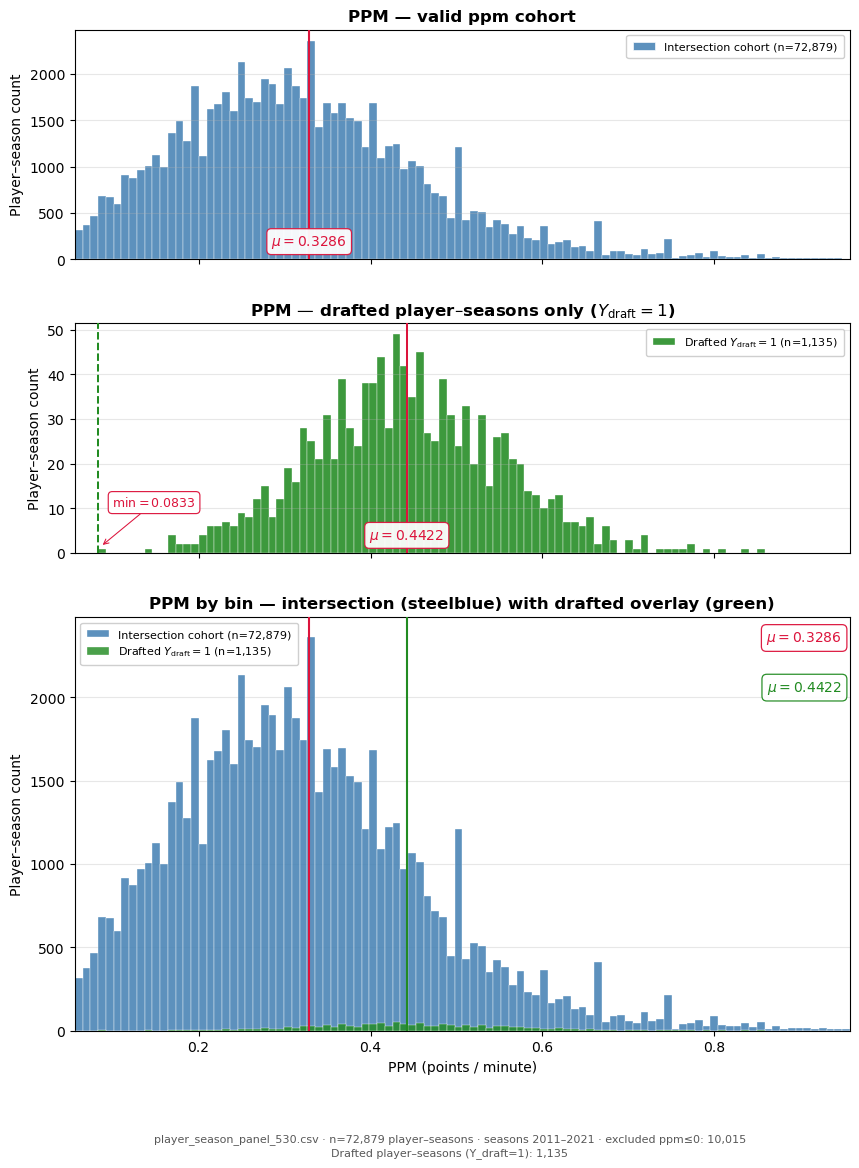

Panel: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/datasets/mbb/player_season_panel_530.csv
Excluded player–seasons with ppm <= 0: 10,015
Intersection: player–seasons with Y_draft=1: 1,135
Min PPM among Y_draft=1 (intersection): 0.083333


In [15]:
# CELL 11 — Histogram: PPM for all player–seasons in the 530 panel

from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

# Gated by RUN_CELL11 in sports/sim_config.py. Run Cell 0 first so reload_sim_config() defines it.
if "reload_sim_config" in globals():
    reload_sim_config(verbose=False)
RUN_CELL11 = bool(globals().get("RUN_CELL11", True))


def _hist_xlim(x: np.ndarray, q: tuple[float, float] = (0.01, 0.99)) -> tuple[float, float]:
    """Display x-limits from quantiles (matches prior CELL 11 behavior)."""
    q1, q99 = np.quantile(x, list(q))
    x_lo = max(float(q1) * 0.95, float(np.min(x)) * 0.8)
    return x_lo, float(q99) * 1.05


def _ensure_sports_pipeline_on_syspath() -> None:
    """Resolve `import sports_pipeline` when cwd is repo root or `sports/`."""
    here = Path.cwd().resolve()
    for d in (here, here / "sports"):
        if (d / "sports_pipeline" / "paths.py").is_file():
            s = str(d)
            if s not in sys.path:
                sys.path.insert(0, s)
            return
    raise FileNotFoundError(
        "Could not find sports_pipeline (looked under cwd and cwd/sports). "
        f"cwd={here}"
    )


if RUN_CELL11:
    _ensure_sports_pipeline_on_syspath()
    from sports_pipeline.paths import panel_530_csv

    panel_path = panel_530_csv()
    if not panel_path.is_file():
        raise FileNotFoundError(
            f"Panel CSV not found:\n  {panel_path}\n"
            "Export or rebuild player_season_panel_530.csv (530 / panel_rebuild), then re-run."
        )

    df = pd.read_csv(panel_path, low_memory=False)
    if "ppm" not in df.columns:
        raise KeyError(f"Column 'ppm' missing from {panel_path}")
    df["ppm"] = pd.to_numeric(df["ppm"], errors="coerce")
    if "minutes" in df.columns:
        mins = pd.to_numeric(df["minutes"], errors="coerce")
        df = df.loc[mins > 0]
    df = df.dropna(subset=["ppm"])
    # Drop exact-zero PPM (no scoring in minute terms / aggregation edge cases); keeps the left tail interpretable.
    n_before_pos = len(df)
    df_ppm = df.loc[df["ppm"] > 0].copy()
    n_zero_ppm = n_before_pos - len(df_ppm)
    if "season" not in df_ppm.columns:
        raise KeyError(f"Column 'season' missing from {panel_path}")

    n_ppm = len(df_ppm)
    has_draft_col = "Y_draft" in df_ppm.columns
    if has_draft_col:
        y_num = pd.to_numeric(df_ppm["Y_draft"], errors="coerce")
        df_both = df_ppm.loc[y_num.notna()].copy()
        df_both["Y_draft"] = y_num.loc[y_num.notna()].astype(int)
    else:
        df_both = df_ppm.iloc[0:0].copy()
    n_both = len(df_both)
    n_ppm_only_draft_na = n_ppm - n_both

    print(
        "Cohort sizes (minutes>0, finite ppm, ppm>0): "
        f"n_ppm={n_ppm:,}; with non-missing Y_draft (intersection): n_both={n_both:,}; "
        f"ppm cohort but Y_draft missing: {n_ppm_only_draft_na:,}",
    )
    if n_ppm == n_both and n_ppm > 0:
        print("(For this panel export, PPM cohort and PPM∩Y_draft cohort coincide.)")

    x_ppm = df_ppm["ppm"].to_numpy(dtype=float)
    mu_ppm = float(np.mean(x_ppm))
    s_season_lo = int(df_ppm["season"].min())
    s_season_hi = int(df_ppm["season"].max())
    n_drafted_for_cap = 0
    # Drafted μ / min on panel 1 (same intersection ∪ Y_draft definitions as panels 2–3).
    n_draft_p1 = 0
    mu_draft_p1 = float("nan")
    min_draft_p1 = float("nan")
    if has_draft_col and n_both > 0:
        _dr = df_both["Y_draft"] == 1
        _xd = df_both.loc[_dr, "ppm"].to_numpy(dtype=float)
        n_draft_p1 = int(len(_xd))
        if n_draft_p1:
            mu_draft_p1 = float(np.mean(_xd))
            min_draft_p1 = float(np.min(_xd))

    x_lo1, x_hi1 = _hist_xlim(x_ppm)
    n_bins = 100
    edges = np.linspace(x_lo1, x_hi1, n_bins + 1)

    fig, (ax1, ax2, ax3) = plt.subplots(
        3,
        1,
        sharex=True,
        figsize=(10.0, 13.0),
        gridspec_kw={
            "hspace": 0.22,
            "height_ratios": [1.0, 1.0, 1.8],  # bottom row ~1.4× the height of each top row
        },
    )

    ax1.hist(
        x_ppm,
        bins=edges,
        color="steelblue",
        edgecolor="white",
        linewidth=0.3,
        alpha=0.88,
    )
    ax1.axvline(mu_ppm, color="crimson", ls="-", lw=1.5, zorder=6)
    # if n_draft_p1:
    #     ax1.axvline(mu_draft_p1, color="crimson", ls="--", lw=1.45, zorder=6)
        # ax1.axvline(min_draft_p1, color="forestgreen", ls="--", lw=1.45, zorder=6)
    ax1.set_ylabel("Player–season count")
    ax1.set_xlim(x_lo1, x_hi1)
    ax1.set_title("PPM — valid ppm cohort", fontsize=12, fontweight="semibold")
    ax1.grid(True, axis="y", alpha=0.3)
    trans1 = mtransforms.blended_transform_factory(ax1.transData, ax1.transAxes)
    ax1.annotate(
        rf"$\mu = {mu_ppm:.4f}$",
        xy=(mu_ppm, 0.04),
        xycoords=trans1,
        ha="center",
        va="bottom",
        fontsize=10,
        color="crimson",
        fontweight="semibold",
        clip_on=False,
        zorder=20,
        bbox=dict(
            boxstyle="round,pad=0.32",
            facecolor="white",
            edgecolor="crimson",
            linewidth=0.9,
            alpha=0.94,
        ),
    )
    if has_draft_col and n_both > 0 and n_draft_p1:
        leg1 = ax1.legend(
            handles=[
                Patch(
                    facecolor="steelblue",
                    edgecolor="white",
                    linewidth=0.5,
                    alpha=0.88,
                    label=f"Intersection cohort (n={n_both:,})",
                ),
                # Patch(
                #     facecolor="forestgreen",
                #     edgecolor="white",
                #     linewidth=0.5,
                #     alpha=0.82,
                #     label=rf"Drafted $Y_{{\mathrm{{draft}}}}=1$ (n={n_draft_p1:,})",
                # ),
            ],
            loc="upper right",
            fontsize=8,
            framealpha=0.94,
            fancybox=True,
            borderpad=0.6,
        )
        if leg1 is not None:
            leg1.set_zorder(50)

    if not has_draft_col or n_both == 0:
        msg = "No Y_draft column or no rows with both ppm and Y_draft observed."
        for ax in (ax2, ax3):
            ax.text(
                0.5,
                0.5,
                msg,
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=11,
            )
            ax.set_axis_off()
    else:
        x = df_both["ppm"].to_numpy(dtype=float)
        drafted = df_both["Y_draft"] == 1
        x_draft = df_both.loc[drafted, "ppm"].to_numpy(dtype=float)
        n_drafted_ps = int(len(x_draft))
        n_drafted_for_cap = n_drafted_ps
        mu_b = float(np.mean(x))
        min_draft_ppm = float(np.min(x_draft)) if n_drafted_ps else float("nan")
        mu_draft = float(np.mean(x_draft)) if n_drafted_ps else float("nan")

        # Middle: drafted PPM only; same bin edges and x-limits as top panel (sharex).
        if n_drafted_ps:
            ax2.hist(
                x_draft,
                bins=edges,
                color="forestgreen",
                edgecolor="white",
                linewidth=0.3,
                alpha=0.88,
                label=rf"Drafted $Y_{{\mathrm{{draft}}}}=1$ (n={n_drafted_ps:,})",
            )
        else:
            ax2.text(
                0.5,
                0.5,
                "No drafted player–seasons (Y_draft = 1) in the intersection cohort.",
                ha="center",
                va="center",
                transform=ax2.transAxes,
                fontsize=11,
            )
        if n_drafted_ps:
            ax2.axvline(mu_draft, color="crimson", ls="-", lw=1.45, zorder=6)
            ax2.axvline(min_draft_ppm, color="forestgreen", ls="--", lw=1.45, zorder=6)
        ax2.set_ylabel("Player–season count")
        ax2.set_title(
            "PPM — drafted player–seasons only ($Y_{\\mathrm{draft}} = 1$)",
            fontsize=12,
            fontweight="semibold",
        )
        ax2.grid(True, axis="y", alpha=0.3, zorder=0)
        if n_drafted_ps:
            leg2 = ax2.legend(loc="upper right", fontsize=8, framealpha=0.94, fancybox=True, borderpad=0.6)
            if leg2 is not None:
                leg2.set_zorder(50)
            trans2 = mtransforms.blended_transform_factory(ax2.transData, ax2.transAxes)
            ax2.annotate(
                rf"$\mu = {mu_draft:.4f}$",
                xy=(mu_draft, 0.04),
                xycoords=trans2,
                ha="center",
                va="bottom",
                fontsize=10,
                color="crimson",
                fontweight="semibold",
                clip_on=False,
                zorder=20,
                bbox=dict(
                    boxstyle="round,pad=0.32",
                    facecolor="white",
                    edgecolor="crimson",
                    linewidth=0.9,
                    alpha=0.94,
                ),
            )
        if n_drafted_ps:
            trans3d = mtransforms.blended_transform_factory(ax2.transData, ax2.transAxes)
            ax2.annotate(
                rf"$\min = {min_draft_ppm:.4f}$",
                xy=(min_draft_ppm, 0.02),
                xycoords=trans3d,
                # xytext=(12, 10),
                xytext=(10, 28),
                textcoords="offset points",
                ha="left",
                va="bottom",
                fontsize=9,
                color="crimson",
                fontweight="semibold",
                clip_on=False,
                zorder=40,
                bbox=dict(
                    boxstyle="round,pad=0.32",
                    facecolor="white",
                    edgecolor="crimson",
                    linewidth=0.85,
                    alpha=0.96,
                ),
                arrowprops=dict(
                    arrowstyle="->",
                    color="crimson",
                    lw=0.75,
                    shrinkA=0,
                    shrinkB=4,
                ),
            )

        # Bottom: same bins — blue = intersection counts, green = drafted counts (overlay, single y-axis).
        counts_int, _ = np.histogram(x, bins=edges)
        counts_d, _ = np.histogram(x_draft, bins=edges)
        w = np.diff(edges)
        ax3.bar(
            edges[:-1],
            counts_int,
            width=w,
            align="edge",
            color="steelblue",
            alpha=0.88,
            edgecolor="white",
            linewidth=0.3,
            label=f"Intersection cohort (n={n_both:,})",
            zorder=2,
        )
        ax3.bar(
            edges[:-1],
            counts_d,
            width=w,
            align="edge",
            color="forestgreen",
            alpha=0.82,
            edgecolor="white",
            linewidth=0.3,
            label=rf"Drafted $Y_{{\mathrm{{draft}}}}=1$ (n={n_drafted_ps:,})",
            zorder=4,
        )
        ax3.axvline(mu_b, color="crimson", ls="-", lw=1.5, zorder=6)
        if n_drafted_ps:
            ax3.axvline(mu_draft, color="forestgreen", ls="-", lw=1.5, zorder=6)
        ax3.set_xlabel("PPM (points / minute)")
        ax3.set_ylabel("Player–season count")
        ax3.set_title(
            "PPM by bin — intersection (steelblue) with drafted overlay (green)",
            fontsize=12,
            fontweight="semibold",
        )
        ax3.grid(True, axis="y", alpha=0.3, zorder=0)
        leg3 = ax3.legend(
            loc="upper left",
            fontsize=8,
            framealpha=0.94,
            fancybox=True,
            borderpad=0.6,
        )
        if leg3 is not None:
            leg3.set_zorder(50)
        ax3.text(
            0.99,
            0.97,
            rf"$\mu = {mu_b:.4f}$",
            transform=ax3.transAxes,
            ha="right",
            va="top",
            fontsize=10,
            color="crimson",
            fontweight="semibold",
            zorder=40,
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="white",
                edgecolor="crimson",
                linewidth=0.9,
                alpha=0.96,
            ),
        )
        if n_drafted_ps:
            ax3.text(
                0.99,
                0.85,
                rf"$\mu = {mu_draft:.4f}$",
                transform=ax3.transAxes,
                ha="right",
                va="top",
                fontsize=10,
                color="forestgreen",
                fontweight="semibold",
                zorder=40,
                bbox=dict(
                    boxstyle="round,pad=0.35",
                    facecolor="white",
                    edgecolor="forestgreen",
                    linewidth=0.9,
                    alpha=0.96,
                ),
            )
    cap_lines = [
        f"{panel_path.name} · n={n_ppm:,} player–seasons · seasons {s_season_lo}–{s_season_hi} · "
        f"excluded ppm≤0: {n_zero_ppm:,}",
    ]
    if n_ppm_only_draft_na:
        cap_lines.append(f"ppm rows missing Y_draft (excluded from panel 2 intersection): {n_ppm_only_draft_na:,}")
    if n_drafted_for_cap:
        cap_lines.append(f"Drafted player–seasons (Y_draft=1): {n_drafted_for_cap:,}")
    fig.text(
        0.5,
        0.012,
        "\n".join(cap_lines),
        ha="center",
        va="bottom",
        fontsize=8,
        color="0.34",
        linespacing=1.35,
    )
    fig.tight_layout(rect=[0, 0.07, 1, 0.99])
    plt.show()
    print("Panel:", panel_path)
    print("Excluded player–seasons with ppm <= 0:", f"{n_zero_ppm:,}")
    if has_draft_col and n_both > 0:
        drafted_b = df_both["Y_draft"] == 1
        n_drafted_ps = int(drafted_b.sum())
        print("Intersection: player–seasons with Y_draft=1:", f"{n_drafted_ps:,}")
        if n_drafted_ps:
            print(
                "Min PPM among Y_draft=1 (intersection):",
                f"{float(df_both.loc[drafted_b, 'ppm'].min()):.6f}",
            )
else:
    print("CELL 11 skipped (RUN_CELL11 = False)")
